# 03｜训练第一个 MLP

本页只训练一个模型。运行后重点观察决策边界如何随 Epoch 逐渐形成，
不需要先追求最高准确率。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "mlp_lab").is_dir():
    LAB_DIR = (Path.cwd() / "01_mlp_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from mlp_lab import quick_demo

## 在三分类螺旋数据上训练

共享服务器默认使用 CPU。只有获得课堂分配后，才使用第 `x` 块 GPU。


配置对比
--------------------------------------------------------------------------------------
配置                                   测试准确率         参数量       耗时(秒)          末轮梯度
--------------------------------------------------------------------------------------
spiral｜relu｜adam                    98.2%       1,251        0.21        0.6667
--------------------------------------------------------------------------------------


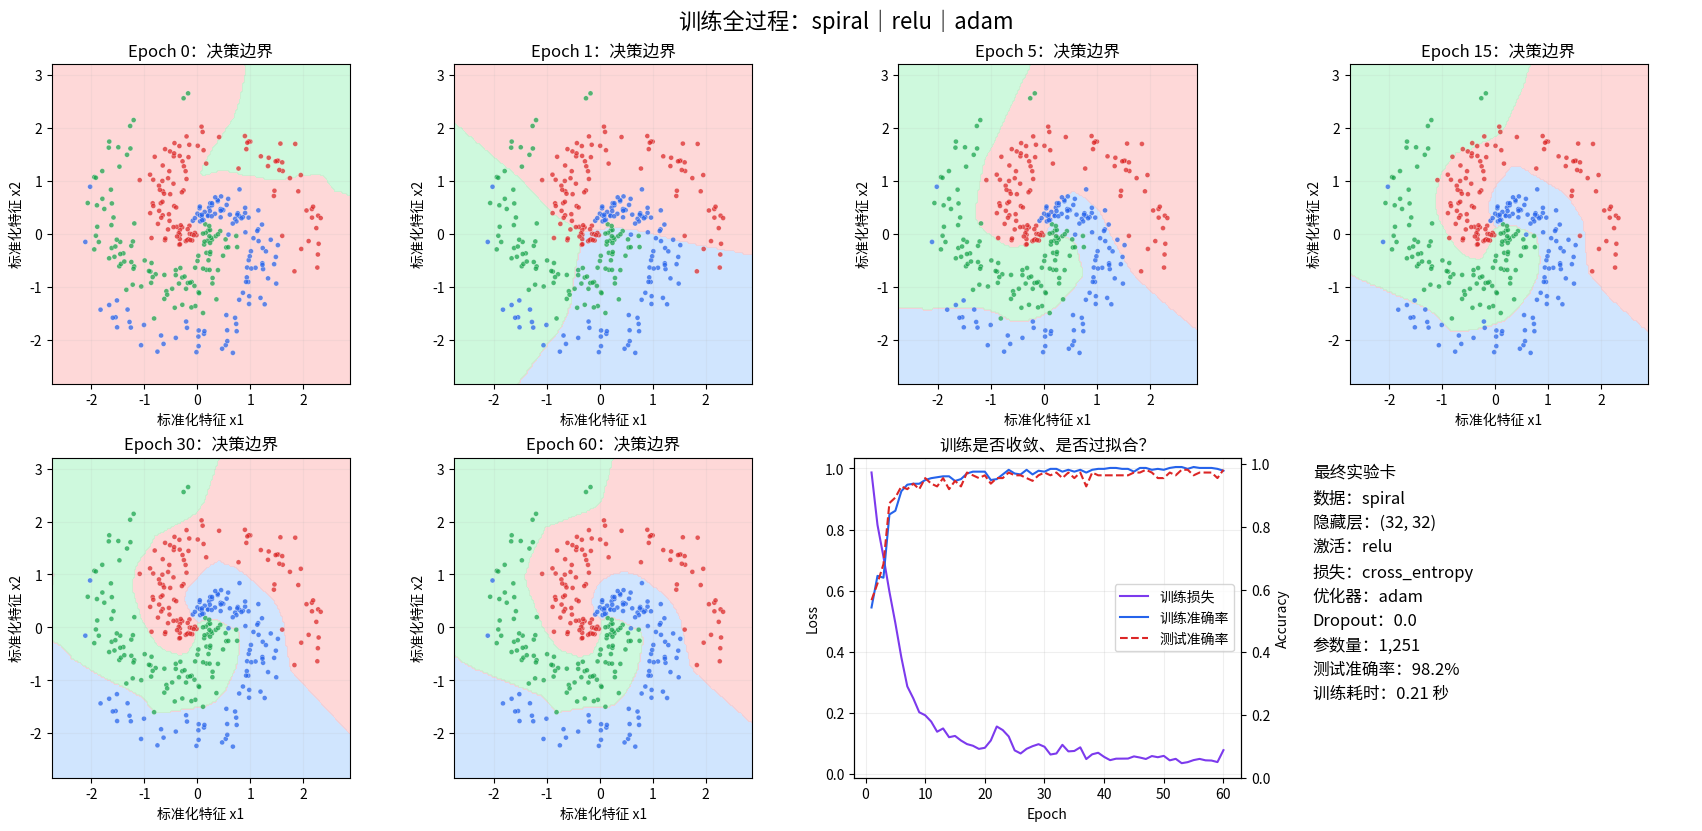

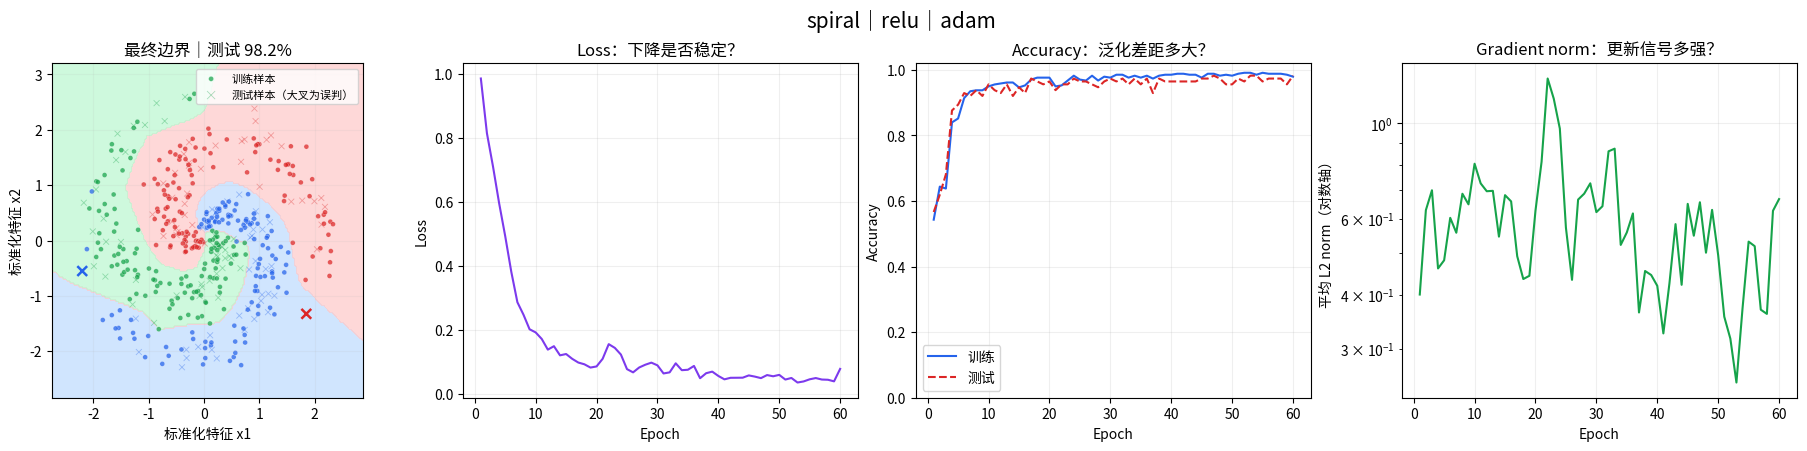

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

result = quick_demo(
    dataset="spiral",
    hidden_sizes=(32, 32),
    activation="relu",
    optimizer="adam",
    device=DEVICE,
    epochs=60,
    n_samples=450,
)

## 模型内部有哪些层

In [3]:
print(result.model)
print("可训练参数量：", result.parameter_count)

MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)
可训练参数量： 1251


**观察顺序：**先看边界形状，再看 Loss 是否下降，最后比较训练集与测试集
Accuracy。一次实验只能说明当前数据、参数和随机种子下的现象。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [4]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……

{'status': 'ok', 'restart': False}